In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, f1_score

from xgboost import XGBClassifier
import shap

In [2]:
df = pd.read_csv("./data/clinvar_conflicting.csv", low_memory=False)
df = df[df["CLASS"].isin([0,1])]
df["label"] = df["CLASS"]
df.head()

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,...,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62,label
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,...,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0,0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,...,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0,0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,...,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0,1
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,...,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN,0
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,...,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0,0


In [3]:
df["AF_ESP"] = df["AF_ESP"].fillna(0)
df["AF_EXAC"] = df["AF_EXAC"].fillna(0)
df["AF_TGP"] = df["AF_TGP"].fillna(0)

df["maf_mean"] = df[["AF_ESP","AF_EXAC","AF_TGP"]].mean(axis=1)

epsilon = 1e-6
df["maf_log"] = -np.log10(df["maf_mean"] + epsilon)

df["radical_change"] = df["BLOSUM62"].apply(
    lambda x: 1 if pd.notnull(x) and x < 0 else 0
)

df["SIFT_score"] = df["SIFT"].str.extract(r"\((.*?)\)")
df["PolyPhen_score"] = df["PolyPhen"].str.extract(r"\((.*?)\)")

df["SIFT_score"] = pd.to_numeric(df["SIFT_score"], errors="coerce")
df["PolyPhen_score"] = pd.to_numeric(df["PolyPhen_score"], errors="coerce")

In [4]:
impact_encoder = LabelEncoder()
df["IMPACT_encoded"] = impact_encoder.fit_transform(df["IMPACT"].astype(str))

features = [
    "maf_log",
    "CADD_PHRED",
    "SIFT_score",
    "PolyPhen_score",
    "BLOSUM62",
    "radical_change",
    "IMPACT_encoded"
]

X = df[features]
y = df["label"]

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

/Users/shen/Explainable-Genomic-Variant-Classification/.venv/lib/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['SIFT_score' 'PolyPhen_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("F1 Score:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85      9751
           1       0.51      0.18      0.27      3287

    accuracy                           0.75     13038
   macro avg       0.64      0.56      0.56     13038
weighted avg       0.71      0.75      0.70     13038

ROC-AUC: 0.7362155518470143
F1 Score: 0.26864330637915546


In [7]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features[:X.shape[1]],
    "importance": importance
}).sort_values(by="importance", ascending=False)

feat_imp

,feature,importance
0,maf_log,0.590422
4,BLOSUM62,0.237596
1,CADD_PHRED,0.070810
3,PolyPhen_score,0.057266
2,SIFT_score,0.043905


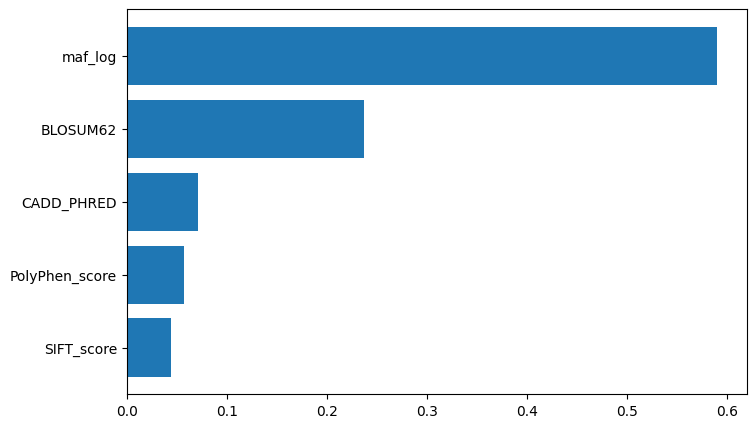

In [8]:
plt.figure(figsize=(8,5))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.show()

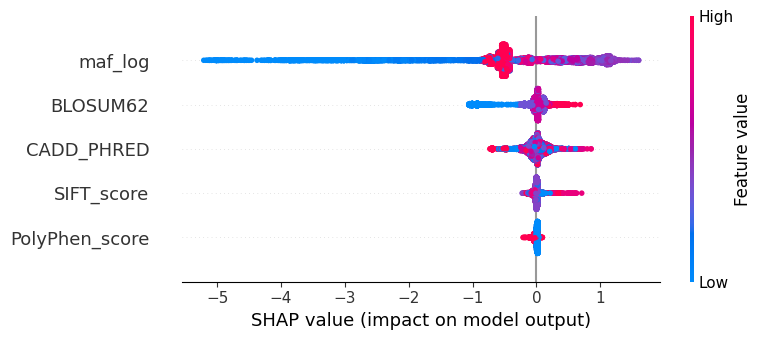

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)